**K-means clustering**

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

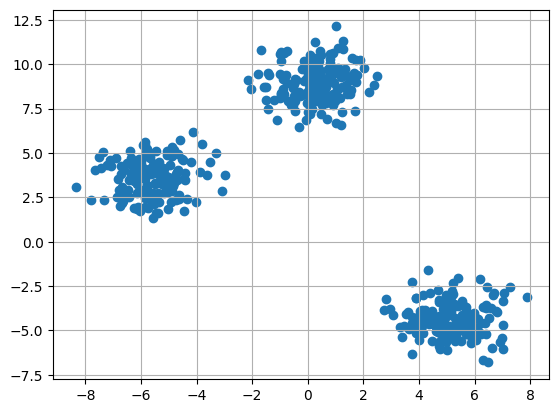

In [76]:
X, y = make_blobs(n_samples=500, n_features=2, centers=3, random_state=23)
plt.grid(True)
plt.scatter(X[:,0], X[:,1])
plt.show()

In [77]:
k = 3

clusters = {}
np.random.seed(23)

# Initialize centers by randomly selecting k points from data
random_indices = np.random.choice(X.shape[0], k, replace=False)

for idx in range(k):
  center = X[random_indices[idx]]
  cluster = {
    'center' : center,
    'points' : []
  }
  
  clusters[idx] = cluster
    
clusters

{0: {'center': array([-0.97859035,  8.31733189]), 'points': []},
 1: {'center': array([-6.45623663,  2.93950572]), 'points': []},
 2: {'center': array([-6.67547543,  2.18692912]), 'points': []}}

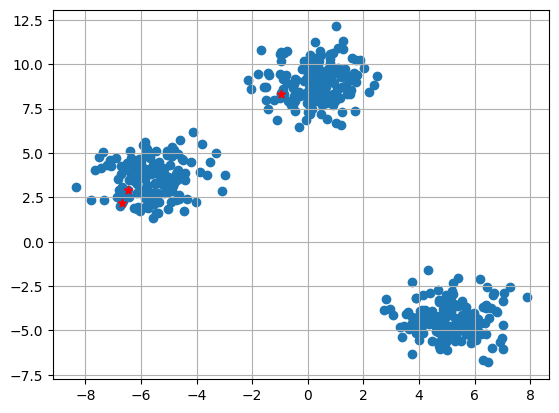

In [78]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1], marker='*', c='red')
plt.show()

In [79]:
# eculidean distance
def euclidean_distance(p1, p2):
  return np.sqrt(np.sum((p1-p2)**2))

In [80]:
def assign_cluster(X, cluster):
  for idx in range(X.shape[0]):
    dist = []

    curr_x = X[idx]
    for i in range(k):
      dis = euclidean_distance(curr_x, clusters[i]['center'])
      dist.append(dis)

    curr_cluster = np.argmin(dist)
    clusters[curr_cluster]['points'].append(curr_x)

  return clusters


def update_cluster(X, clusters):
  for i in range(k):
    points = np.array(clusters[i]['points'])

    if points.shape[0] > 0:
      new_center = points.mean(axis=0)
      clusters[i]['center'] = new_center

      clusters[i]['points'] = []
    
  return clusters

In [81]:
def pred_cluster(X, clusters):
  pred = []
  for i in range(X.shape[0]):
    dist = []
    for j in range(k):
      dist.append(euclidean_distance(X[i],clusters[j]['center']))
    pred.append(np.argmin(dist))
  return pred

In [82]:
# Run k-means for multiple iterations until convergence
max_iterations = 20
for iteration in range(max_iterations):
    clusters = assign_cluster(X, clusters)
    clusters = update_cluster(X, clusters)

pred = pred_cluster(X, clusters)

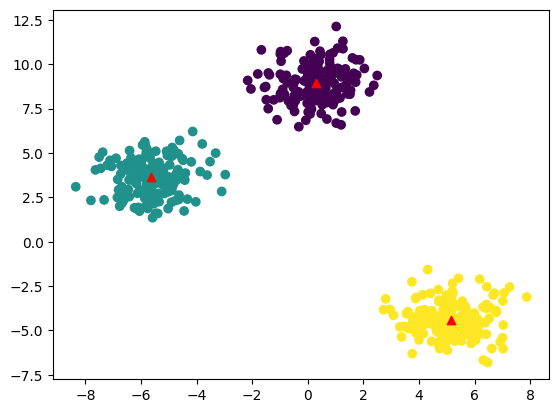

In [83]:
plt.scatter(X[:,0], X[:,1], c=pred)
for i in clusters:
  center = clusters[i]['center']
  plt.scatter(center[0], center[1], marker='^', c='red')

plt.show()